# Beautry Marketplace Sales Analysis

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
product = pd.read_csv('product_code - Sheet1.csv')
transactions = pd.read_csv('transactions - Sheet1.csv')

## Data Understanding

### Sample Data

In [20]:
# Melihat 5 data teratas
pd.set_option('display.max_columns', None)
display(product.head())
display(transactions.head())

,product_code,product_name,category,sub_category,shade,finish_type,skin_type_target,size_ml,launch_year,product_status,production_cost,selling_price,brand,local_or_import,halal_certified,vegan_product,bpom_registered,supplier_name,warehouse_location,stock_qty,reorder_point,rating_average,review_count
0,PRD-0001,Velvet Air Cushion,Cushion,Cushion,Ivory Beige,Satin,Oily,5,2023,Active,103810,148402,Lunelle Beauty,Local,Yes,No,Yes,PT Beauty Ingredient Asia,Jakarta,867,105,4.2,9963
1,PRD-0002,Glow Fit Cushion,Cushion,Cushion,Dark Brown,Natural,Oily,10,2026,Active,23478,127041,Lunelle Beauty,Local,Yes,Yes,Yes,PT Cosmetic Base Nusantara,Medan,2887,121,4.2,12609
2,PRD-0003,Hydra Skin Cushion,Cushion,Cushion,Natural Beige,Natural,Dry,8,2024,Active,64118,107514,Lunelle Beauty,Local,Yes,No,Yes,PT Cosmetic Base Nusantara,Jakarta,3200,70,4.6,13688
3,PRD-0004,Silk Two Way Cake,Two Way Cake,Two Way Cake,Peach Nude,Dewy,Dry,3,2023,Active,102397,213467,Lunelle Beauty,Local,Yes,Yes,Yes,PT Beauty Ingredient Asia,Medan,2377,166,4.6,6077
4,PRD-0005,Soft Blur Powder Cake,Two Way Cake,Two Way Cake,Peach Nude,Dewy,Combination,20,2022,Active,41319,119839,Lunelle Beauty,Local,Yes,Yes,Yes,PT Glow Chemical,Medan,2311,286,4.6,9225


,transaction_id,transaction_date,order_time,platform,order_source,customer_id,customer_name,customer_gender,customer_age,city,province,membership_tier,product_code,quantity,gross_sales,discount_amount,net_sales,shipping_cost,platform_fee,payment_method,voucher_used,campaign_name,warehouse_origin,delivery_status,delivery_days,customer_rating,returned_flag,return_reason,sales_channel_type,cashier_or_host
0,TRX-000001,05/03/2026,14:54:18,TikTok Shop,Live,CUST-0799,Aurora Hartati,Male,36,Bogor,Banten,Bronze,PRD-0016,1,92622,11724,80898,12757,4662,COD,No,11.11 Big Sale,Bandung,Delivered,6,3,No,NaN,Online,Tiara
1,TRX-000002,28/01/2026,5:53:02,Shopee,Organic,CUST-0880,KH. Opan Tampubolon,Male,24,Medan,Jawa Barat,Silver,PRD-0020,2,347856,34970,312886,20083,7728,E-wallet,Yes,12.12 Payday,Jakarta,Delivered,6,2,No,NaN,Online,Rina
2,TRX-000003,11/05/2026,16:11:45,Shopee,Live,CUST-0029,Amelia Dongoran,Female,45,Kendari,Jawa Timur,Bronze,PRD-0017,1,79264,9146,70118,13698,2626,Transfer,No,Ramadan Glow Up,Surabaya,Delivered,4,5,No,NaN,Online,Nadya
3,TRX-000004,12/01/2026,14:50:16,TikTok Shop,Organic,CUST-0533,Laila Siregar,Female,28,Pekanbaru,Sumatera Utara,Bronze,PRD-0007,4,805376,151149,654227,15819,12209,E-wallet,Yes,No Campaign,Surabaya,Delivered,5,3,No,NaN,Online,Salsa
4,TRX-000005,02/02/2026,20:00:50,Shopee,Ads,CUST-0694,"Elvina Samosir, M.M.",Female,36,Surabaya,Riau,Bronze,PRD-0016,4,370488,91384,279104,22954,2006,E-wallet,No,12.12 Payday,Medan,Delivered,7,5,No,NaN,Online,Salsa


### Shape & Info

In [4]:
# Melihat shape dataset
display(product.shape)
display(transactions.shape)

(24, 23)

(2500, 30)

In [5]:
# Melihat info dataset
display(product.info(verbose=True,max_cols=None))
display(transactions.info(verbose=True,max_cols=None))


<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_code        24 non-null     str    
 1   product_name        24 non-null     str    
 2   category            24 non-null     str    
 3   sub_category        24 non-null     str    
 4   shade               24 non-null     str    
 5   finish_type         24 non-null     str    
 6   skin_type_target    24 non-null     str    
 7   size_ml             24 non-null     int64  
 8   launch_year         24 non-null     int64  
 9   product_status      24 non-null     str    
 10  production_cost     24 non-null     int64  
 11  selling_price       24 non-null     int64  
 12  brand               24 non-null     str    
 13  local_or_import     24 non-null     str    
 14  halal_certified     24 non-null     str    
 15  vegan_product       24 non-null     str    
 16  bpom_registered     2

None

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   transaction_id      2500 non-null   str  
 1   transaction_date    2500 non-null   str  
 2   order_time          2500 non-null   str  
 3   platform            2500 non-null   str  
 4   order_source        2500 non-null   str  
 5   customer_id         2500 non-null   str  
 6   customer_name       2500 non-null   str  
 7   customer_gender     2500 non-null   str  
 8   customer_age        2500 non-null   int64
 9   city                2500 non-null   str  
 10  province            2500 non-null   str  
 11  membership_tier     2500 non-null   str  
 12  product_code        2500 non-null   str  
 13  quantity            2500 non-null   int64
 14  gross_sales         2500 non-null   int64
 15  discount_amount     2500 non-null   int64
 16  net_sales           2500 non-null   int64
 17  shippi

None

**Finding:** kolom `transaction_date` dan `order_time` perlu diubah ke format datetime

### Descriptive Statistics

In [6]:
# Melihat statistika deskriptif dataset
display(product.describe().T) 
display(transactions.describe().T)

,count,mean,std,min,25%,50%,75%,max
size_ml,24.0,13.208333,9.744471,3.0,4.50,10.0,20.00,30.0
launch_year,24.0,2024.000000,1.414214,2022.0,2023.00,2024.0,2025.00,2026.0
production_cost,24.0,69252.583333,33340.412144,21504.0,46389.75,56524.0,102750.25,117310.0
selling_price,24.0,150491.875000,40923.254960,74525.0,125703.50,148580.0,175813.50,219822.0
stock_qty,24.0,2811.708333,1289.093968,624.0,1946.75,2944.5,4108.50,4746.0
reorder_point,24.0,169.708333,77.493046,67.0,109.00,147.0,252.25,288.0
rating_average,24.0,4.504167,0.323673,4.0,4.20,4.4,4.75,5.0
review_count,24.0,8226.000000,4911.086358,258.0,3278.75,9200.0,12786.25,14393.0


,count,mean,std,min,25%,50%,75%,max
customer_age,2500.0,30.8752,8.297323,17.0,24.00,31.0,38.00,45.0
quantity,2500.0,3.0180,1.400307,1.0,2.00,3.0,4.00,5.0
gross_sales,2500.0,455456.5092,250120.470529,74525.0,243382.00,426934.0,635205.00,1099110.0
discount_amount,2500.0,57291.7676,49333.141180,13.0,19849.00,42933.0,82196.00,267474.0
net_sales,2500.0,398164.7416,221518.998881,57619.0,212766.25,367750.0,554862.00,1097295.0
shipping_cost,2500.0,15100.7692,5769.299608,5007.0,10049.25,15124.0,20083.25,24989.0
platform_fee,2500.0,8372.2240,3675.114665,2006.0,5176.25,8268.5,11514.75,14990.0
delivery_days,2500.0,3.9772,2.021464,1.0,2.00,4.0,6.00,7.0
customer_rating,2500.0,2.9912,1.407094,1.0,2.00,3.0,4.00,5.0


### Duplicate Check

In [7]:
# Memeriksa duplicate value
display(product.duplicated().sum())
display(transactions.duplicated().sum())

np.int64(0)

np.int64(0)

**Finding:** Tidak ada data duplikat

### Missing Value Summary

In [8]:
# Memeriksa missing values
display(product.isna().sum())
display(transactions.isna().sum())

product_code          0
product_name          0
category              0
sub_category          0
shade                 0
finish_type           0
skin_type_target      0
size_ml               0
launch_year           0
product_status        0
production_cost       0
selling_price         0
brand                 0
local_or_import       0
halal_certified       0
vegan_product         0
bpom_registered       0
supplier_name         0
warehouse_location    0
stock_qty             0
reorder_point         0
rating_average        0
review_count          0
dtype: int64

transaction_id           0
transaction_date         0
order_time               0
platform                 0
order_source             0
customer_id              0
customer_name            0
customer_gender          0
customer_age             0
city                     0
province                 0
membership_tier          0
product_code             0
quantity                 0
gross_sales              0
discount_amount          0
net_sales                0
shipping_cost            0
platform_fee             0
payment_method           0
voucher_used             0
campaign_name            0
warehouse_origin         0
delivery_status          0
delivery_days            0
customer_rating          0
returned_flag            0
return_reason         2385
sales_channel_type       0
cashier_or_host          0
dtype: int64

**Finding:** Terdapat missing value di kolom `return_reason` pada dataset `transactions`

### Outlier Check

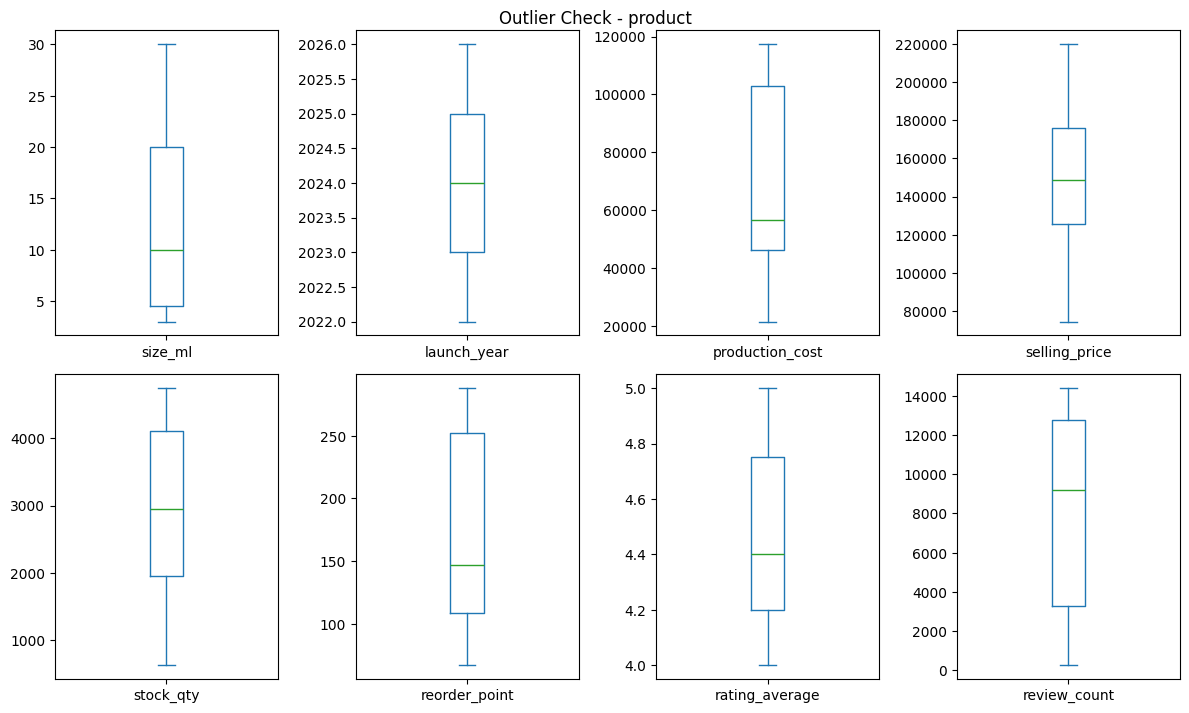

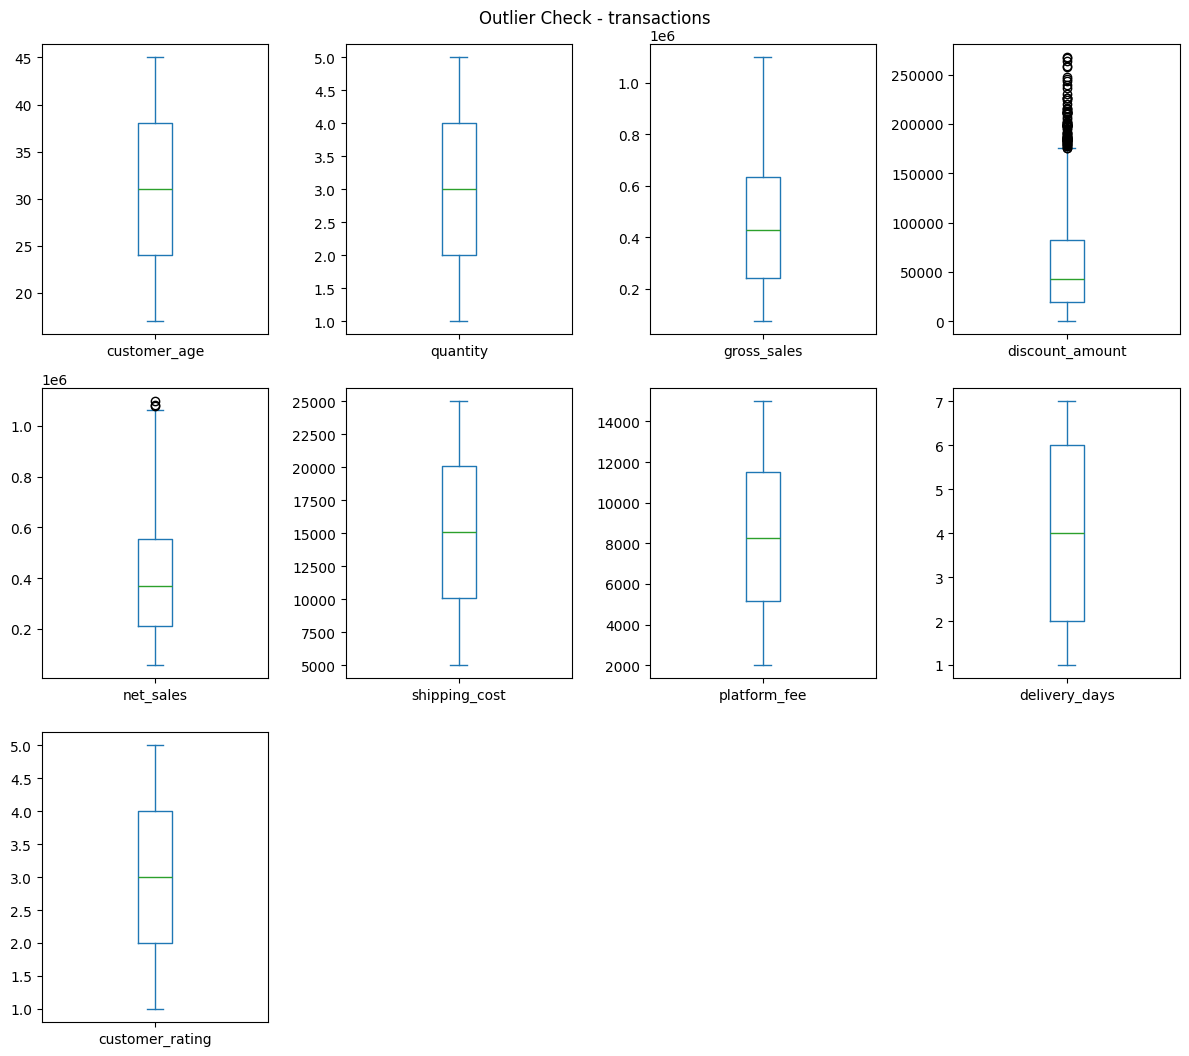

In [49]:
data = {'product': product,'transactions': transactions}
for name, df in data.items():
    df_to_plot = df.select_dtypes(include=['int','float'])

    df_to_plot.plot(subplots=True, layout=(4,4), kind='box', figsize=(12,14))
    plt.suptitle(f'Outlier Check - {name}')
    plt.tight_layout()

**Finding:** Mayoritas kolom numerik tidak menunjukkan outlier signifikan, namun perlu dicek lebih dalam untuk kolom `discount_amount`untuk rentang 175000 ke atas

In [47]:
print(f'rata-rata quantity tanpa outlier: ',transactions[transactions['discount_amount']<=175000]['quantity'].mean())
print(f'rata-rata quantity dengan outlier: ',transactions[transactions['discount_amount']>175000]['quantity'].mean())
print(f'rata-rata gross_sales tanpa outlier: ',transactions[transactions['discount_amount']<=175000]['gross_sales'].mean())
print(f'rata-rata gross_sales dengan outlier: ',transactions[transactions['discount_amount']>175000]['gross_sales'].mean())


rata-rata quantity tanpa outlier:  2.9598842018196856
rata-rata quantity dengan outlier:  4.7317073170731705
rata-rata gross_sales tanpa outlier:  439678.3548387097
rata-rata gross_sales dengan outlier:  920719.6463414634


**Finding:** Outlier pada kolom `discount_amount`(>175000) berkorelasi dengan transaksi quantity tinggi (rata-rata 4.73 vs 2.96) dan gross_sales besar (rata-rata 920719 vs 439678). Mengindikasikan transaksi bulk/produk premium dengan diskon besar. Outlier dianggap wajar sehingga tidak dilakukan penanganan.

### Inconsistency Data Check

In [32]:
data = {'product': product,'transactions': transactions}
for name, df in data.items():
    print(f'\n{'='*50}')
    print(f' DataFrame: {name}')
    print(f'\n{'='*50}')
    cat_col = df.select_dtypes(include='str').columns

    for col in cat_col:
        # Cek Whitespace
        has_whitespace = df[col].str.strip().ne(df[col]).sum()
        # Cek kapitalisasi tidak konsisten
        has_case = df[col].str.strip().str.lower().nunique() != df[col].nunique()
        
        print(f"\n{col} ({df[col].nunique()} unique):")
        print(f'Whitespace issue: {has_whitespace} baris')
        print(f'Case inconsistent: {has_case}')


 DataFrame: product


product_code (24 unique):
Whitespace issue: 0 baris
Case inconsistent: False

product_name (24 unique):
Whitespace issue: 0 baris
Case inconsistent: False

category (10 unique):
Whitespace issue: 0 baris
Case inconsistent: False

sub_category (10 unique):
Whitespace issue: 0 baris
Case inconsistent: False

shade (8 unique):
Whitespace issue: 0 baris
Case inconsistent: False

finish_type (4 unique):
Whitespace issue: 0 baris
Case inconsistent: False

skin_type_target (4 unique):
Whitespace issue: 0 baris
Case inconsistent: False

product_status (2 unique):
Whitespace issue: 0 baris
Case inconsistent: False

brand (1 unique):
Whitespace issue: 0 baris
Case inconsistent: False

local_or_import (2 unique):
Whitespace issue: 0 baris
Case inconsistent: False

halal_certified (1 unique):
Whitespace issue: 0 baris
Case inconsistent: False

vegan_product (2 unique):
Whitespace issue: 0 baris
Case inconsistent: False

bpom_registered (1 unique):
Whitespace issue: 0 baris
C

**Finding:** Whitespace di kolom `return_reason`, jumlahnya sama dengan missing value (2385 baris) diduga karena tersimpan sebagai string kosong/spasi

### Business Rule Validation

In [29]:
# Join kedua dataset
merged = transactions.merge(
    product[['product_code','selling_price']],
    on='product_code',
    how='left')
# Validasi gross_sales
print(f'jumlah row valid pada gross_sales: {(merged['gross_sales'] == merged['selling_price'] * merged['quantity']).sum()}')
print(f'jumlah row valid pada net_sales: {(merged['net_sales'] == merged['gross_sales'] - merged['discount_amount']).sum()}')


jumlah row valid pada gross_sales: 2500
jumlah row valid pada net_sales: 2500


## Data Cleaning


### Handle Missing Values

In [10]:
# Memeriksa proporsi missing value berdasarkan returned_flag
transactions.groupby('returned_flag')['return_reason'].apply(lambda x: x.isna().sum()/len(transactions)*100)

returned_flag
No     94.6
Yes     0.8
Name: return_reason, dtype: float64

Missing value yang terjadi karena `returned_flag` dengan status *No* akan kita isi dengan 'No Return', sedangkan dengan status *Yes* akan dihapus karena proporsinya <5%

In [11]:
# Mengisi 'No Return' pada missing values
no_return = transactions[transactions['returned_flag']=='No'].fillna('No Return')
# Menghapus missing values
yes_return = transactions[transactions['returned_flag']=='Yes'].dropna()
# Menggabungkan kembali
transactions_no_missing = pd.concat([no_return, yes_return]).sort_index()


### Fix Data Types

In [50]:
transactions_no_missing['transaction_date'] = pd.to_datetime(transactions_no_missing['transaction_date'],format='%d/%m/%Y')
transactions_no_missing['order_time'] = pd.to_datetime(transactions_no_missing['order_time'],format='%H:%M:%S').dt.time
transactions_no_missing.info()

<class 'pandas.DataFrame'>
Index: 2480 entries, 0 to 2499
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      2480 non-null   str           
 1   transaction_date    2480 non-null   datetime64[us]
 2   order_time          2480 non-null   object        
 3   platform            2480 non-null   str           
 4   order_source        2480 non-null   str           
 5   customer_id         2480 non-null   str           
 6   customer_name       2480 non-null   str           
 7   customer_gender     2480 non-null   str           
 8   customer_age        2480 non-null   int64         
 9   city                2480 non-null   str           
 10  province            2480 non-null   str           
 11  membership_tier     2480 non-null   str           
 12  product_code        2480 non-null   str           
 13  quantity            2480 non-null   int64         
 14  gross_sa

## Export Data

In [52]:
# Export dataset product
product.to_csv('product_clean_csv', index=False)
# Export dataset transactions
transactions_no_missing.to_csv('transactions_clean_csv', index=False)